   5  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.608  0.609  0.610  \
0  0  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  4  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.611  0.612  0.613  0.614  0.615  0.616  0.617  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]


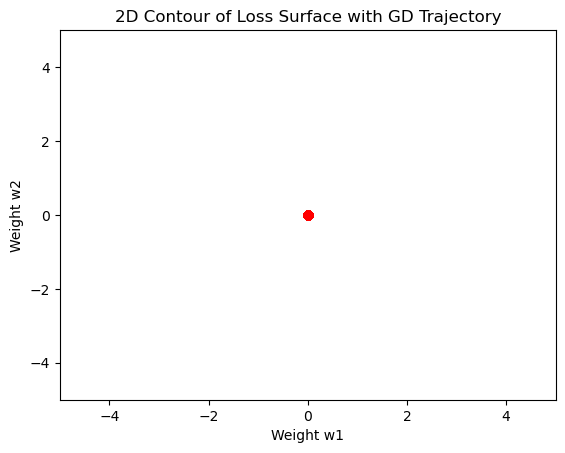

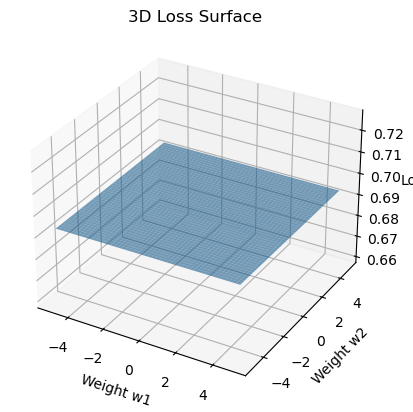

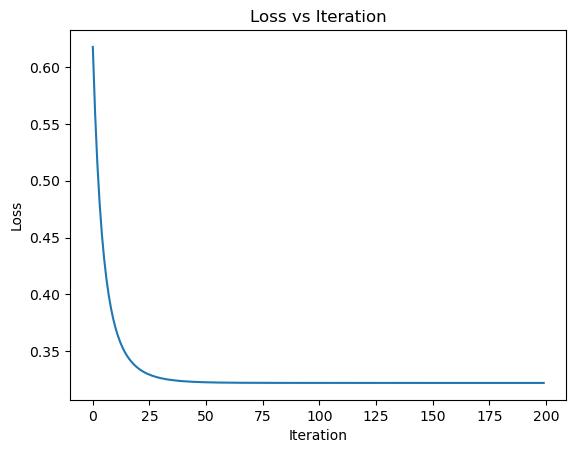

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (fix path + filename)
df = pd.read_csv(r"C:\Users\kumar\Downloads\mnist_train.csv")

# Show first rows
print(df.head())

# Target (0 vs not 0 classification)
y = (df.iloc[:, 0] == 0).astype(int).values.reshape(-1, 1)

# Features (take only 2 features for visualization)
X = df.iloc[:, 1:3].values   # using 2 features only

# Normalize
X = X / 255.0

# Add bias term
X = np.hstack((np.ones((X.shape[0], 1)), X))


# 🔷 Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# 🔷 Loss Function
def loss(w):
    h = sigmoid(X @ w)
    return -np.mean(y * np.log(h + 1e-8) + (1 - y) * np.log(1 - h + 1e-8))


# 🔷 Gradient
def gradient(w):
    h = sigmoid(X @ w)
    return (1 / len(y)) * (X.T @ (h - y))


# 🔷 Gradient Descent
def gradient_descent(w, lr=0.5, iters=200):
    losses = []
    path = []

    for i in range(iters):
        w = w - lr * gradient(w)
        path.append(w.copy())
        losses.append(loss(w))

    return w, losses, np.array(path)


# Initialize weights
w_init = np.zeros((X.shape[1], 1))

# Train
w_final, losses, path = gradient_descent(w_init)


# 🔷 Create Loss Surface
w1 = np.linspace(-5, 5, 50)
w2 = np.linspace(-5, 5, 50)

W1, W2 = np.meshgrid(w1, w2)
Z = np.zeros(W1.shape)

for i in range(len(w1)):
    for j in range(len(w2)):
        temp_w = np.array([[0], [W1[i, j]], [W2[i, j]]])
        Z[i, j] = loss(temp_w)


# 🔷 2D Contour Plot
plt.figure()
plt.contour(W1, W2, Z, levels=30)
plt.plot(path[:, 1], path[:, 2], 'r-o')
plt.xlabel("Weight w1")
plt.ylabel("Weight w2")
plt.title("2D Contour of Loss Surface with GD Trajectory")
plt.show()


# 🔷 3D Surface Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, Z, alpha=0.6)
ax.set_xlabel("Weight w1")
ax.set_ylabel("Weight w2")
ax.set_zlabel("Loss")
ax.set_title("3D Loss Surface")
plt.show()


# 🔷 Loss vs Iteration
plt.figure()
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iteration")
plt.show()

   5  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.608  0.609  0.610  \
0  0  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  4  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  1  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.611  0.612  0.613  0.614  0.615  0.616  0.617  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]


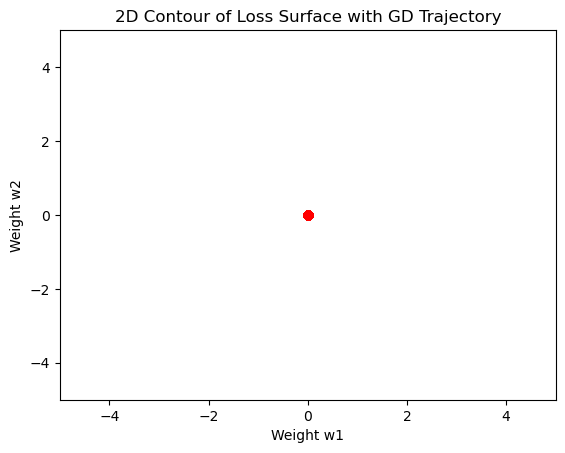

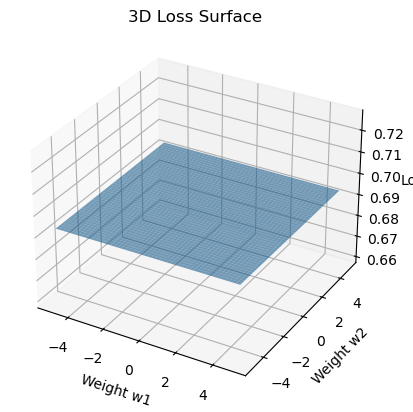

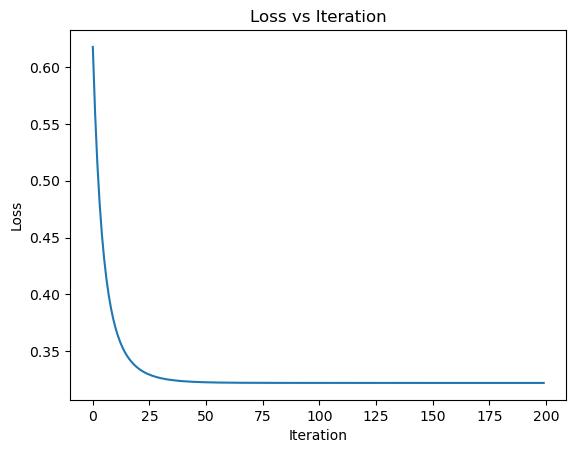

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (fix path + filename)
df = pd.read_csv(r"C:\Users\kumar\Downloads\mnist_train.csv")

# Show first rows
print(df.head())

# Target (0 vs not 0 classification)
y = (df.iloc[:, 0] == 0).astype(int).values.reshape(-1, 1)

# Features (take only 2 features for visualization)
X = df.iloc[:, 1:3].values   # using 2 features only

# Normalize
X = X / 255.0

# Add bias term
X = np.hstack((np.ones((X.shape[0], 1)), X))


# 🔷 Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# 🔷 Loss Function
def loss(w):
    h = sigmoid(X @ w)
    return -np.mean(y * np.log(h + 1e-8) + (1 - y) * np.log(1 - h + 1e-8))


# 🔷 Gradient
def gradient(w):
    h = sigmoid(X @ w)
    return (1 / len(y)) * (X.T @ (h - y))


# 🔷 Gradient Descent
def gradient_descent(w, lr=0.5, iters=200):
    losses = []
    path = []

    for i in range(iters):
        w = w - lr * gradient(w)
        path.append(w.copy())
        losses.append(loss(w))

    return w, losses, np.array(path)


# Initialize weights
w_init = np.zeros((X.shape[1], 1))

# Train
w_final, losses, path = gradient_descent(w_init)


# 🔷 Create Loss Surface
w1 = np.linspace(-5, 5, 50)
w2 = np.linspace(-5, 5, 50)

W1, W2 = np.meshgrid(w1, w2)
Z = np.zeros(W1.shape)

for i in range(len(w1)):
    for j in range(len(w2)):
        temp_w = np.array([[0], [W1[i, j]], [W2[i, j]]])
        Z[i, j] = loss(temp_w)


# 🔷 2D Contour Plot
plt.figure()
plt.contour(W1, W2, Z, levels=30)
plt.plot(path[:, 1], path[:, 2], 'r-o')
plt.xlabel("Weight w1")
plt.ylabel("Weight w2")
plt.title("2D Contour of Loss Surface with GD Trajectory")
plt.show()


# 🔷 3D Surface Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, Z, alpha=0.6)
ax.set_xlabel("Weight w1")
ax.set_ylabel("Weight w2")
ax.set_zlabel("Loss")
ax.set_title("3D Loss Surface")
plt.show()


# 🔷 Loss vs Iteration
plt.figure()
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iteration")
plt.show()